In [1]:
import sys
sys.path.insert(0, '/home/i_am_helium/my_libs')

In [2]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

In [3]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import cv2
import os
import shutil
import itertools

import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import random
import copy
import pickle

import warnings
warnings.filterwarnings('ignore')

In [8]:
import os
os.environ['PYTHONPATH'] = '/home/i_am_helium/.local/lib/python3.10/site-packages'

import sys
# Put new torch first, then my_libs for numpy
sys.path = ['/home/i_am_helium/.local/lib/python3.10/site-packages'] + \
           [p for p in sys.path if 'my_libs' not in p] + \
           ['/home/i_am_helium/my_libs']


import random
from torchvision import transforms

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0 
import torchvision.models as models
import timm
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.lr_scheduler import CosineAnnealingLR

print(f"Torch version: {torch.__version__}")
print(f"Torch from: {torch.__file__}")

Torch version: 2.5.1+cu121
Torch from: /home/i_am_helium/.local/lib/python3.10/site-packages/torch/__init__.py


In [9]:
import imutils

In [10]:
# ============================================================
# REPRODUCIBILITY SETTINGS
# ============================================================

def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    # CRITICAL: These settings are required for full reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Worker seed function for DataLoader
def seed_worker(worker_id):
    """Seed function for DataLoader workers"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Create generator for DataLoader
g = torch.Generator()
g.manual_seed(42)

# Set number of workers
num_workers = 2

# Call set_seed to initialize
set_seed(42)

print("✅ Reproducibility settings applied")
print(f"   - torch.backends.cudnn.deterministic = {torch.backends.cudnn.deterministic}")
print(f"   - torch.backends.cudnn.benchmark = {torch.backends.cudnn.benchmark}")
print(f"   - Generator seed = 42")
print(f"   - num_workers = {num_workers}")

✅ Reproducibility settings applied
   - torch.backends.cudnn.deterministic = True
   - torch.backends.cudnn.benchmark = False
   - Generator seed = 42
   - num_workers = 2


## Check device - SET CUDA

In [11]:
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("No GPU detected!")

CUDA available: True
CUDA version: 12.1
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 4090
GPU memory: 25.39 GB


In [14]:
import sys
print("Python executable:", sys.executable)
print("\nPython path:")
for p in sys.path:
    print(f"  {p}")

Python executable: /opt/jupyterhub/bin/python3

Python path:
  /home/i_am_helium/.local/lib/python3.10/site-packages
  /usr/lib/python310.zip
  /usr/lib/python3.10
  /usr/lib/python3.10/lib-dynload
  
  /opt/jupyterhub/lib/python3.10/site-packages
  /home/i_am_helium/my_libs
  /tmp/tmpxx3j7a8w


In [15]:
import sys
sys.path.insert(0, '/home/i_am_helium/.local/lib/python3.10/site-packages')

In [16]:
import torch

print("="*60)
print("GPU VERIFICATION")
print("="*60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version (PyTorch): {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"\nGPU detected: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"GPU compute capability: {torch.cuda.get_device_capability(0)}")
    
    # Test GPU với tensor
    device = torch.device('cuda')
    x = torch.randn(1000, 1000).to(device)
    y = torch.randn(1000, 1000).to(device)
    z = torch.matmul(x, y)
    print(f"Test tensor computation on GPU: SUCCESS")
    print(f"Device: {z.device}")
else:
    print("\nGPU NOT DETECTED!")
    print("Restart kernel and try again!")
print("="*60)

GPU VERIFICATION
PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version (PyTorch): 12.1
Number of GPUs: 1

GPU detected: NVIDIA GeForce RTX 4090
GPU memory: 25.39 GB
GPU compute capability: (8, 9)
Test tensor computation on GPU: SUCCESS
Device: cuda:0


In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Create one-single-channel

In [ ]:
def make_single_channel_efficientnet(pretrained=True):
    """
    Create EfficientNet-B0 backbone for single-channel input
    
    Args:
        pretrained: If True, load HAM10000 pretrained weights
                   If False, use random initialization
    """
    from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
    import torch.nn as nn
    
    # Load base EfficientNet-B0
    if pretrained:
        # Load với ImageNet weights - then will replace
        weights = EfficientNet_B0_Weights.DEFAULT
        backbone = efficientnet_b0(weights=weights)
    else:
        backbone = efficientnet_b0(weights=None)
    
    # Convert first conv from 3-channel to 1-channel
    old_conv = backbone.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=1,              # Change from 3 to 1
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )
    
    # Initialize by averaging RGB weights
    if pretrained:
        with torch.no_grad():
            # Average across RGB channels: (out, 3, h, w) → (out, 1, h, w)
            new_conv.weight = nn.Parameter(
                old_conv.weight.mean(dim=1, keepdim=True)
            )
    
    backbone.features[0][0] = new_conv
    
    # Remove classifier (we'll add our own)
    backbone.classifier = nn.Identity()
    
    return backbone.features

## Image-Only Model (Target Model Architecture)

In [20]:
class MultiModalSkinNet(nn.Module):
    """
    Multimodal model: R/G/B channels + metadata
    """
    def __init__(self, metadata_dim, num_classes=4, pretrained=True,
                 freeze_backbone=True, unfreeze_last_n_blocks=0):
        super().__init__()
        
        # Shared backbone
        self.shared_backbone = make_single_channel_efficientnet(pretrained)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.img_dropout = nn.Dropout(0.5)
        
        # Initial freeze/unfreeze
        if freeze_backbone:
            for param in self.shared_backbone.parameters():
                param.requires_grad = False
            
            if unfreeze_last_n_blocks > 0:
                blocks = list(self.shared_backbone.children())
                for block in blocks[-unfreeze_last_n_blocks:]:
                    for param in block.parameters():
                        param.requires_grad = True
        
        # Feature dimensions
        image_feature_dim = 1280  # EfficientNet-B0 output
        fused_image_dim = image_feature_dim * 3  # R + G + B = 3840
        
        # Metadata branch
        self.metadata_branch = nn.Sequential(
            nn.Linear(metadata_dim, 64),
            nn.BatchNorm1d(64, track_running_stats=False),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32, track_running_stats=False),
            nn.ReLU()
        )
        
        # Classifier
        fc_in = fused_image_dim + 32  # 3840 + 32 = 3872
        self.classifier = nn.Sequential(
            nn.Linear(fc_in, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, img_R, img_G, img_B, metadata):
        # Extract features from each channel
        feat_R = self.shared_backbone(img_R)
        feat_G = self.shared_backbone(img_G)
        feat_B = self.shared_backbone(img_B)
        
        # Pool and flatten
        feat_R = self.pool(feat_R).flatten(1)
        feat_G = self.pool(feat_G).flatten(1)
        feat_B = self.pool(feat_B).flatten(1)
        
        # Concatenate image features
        img_features = torch.cat([feat_R, feat_G, feat_B], dim=1)
        img_features = self.img_dropout(img_features)
        
        # Metadata features
        meta_features = self.metadata_branch(metadata)
        
        # Combine and classify
        combined = torch.cat([img_features, meta_features], dim=1)
        out = self.classifier(combined)
        
        return out
    
    # ========================================
    # THÊM METHOD MỚI 1: set_trainable_layers
    # ========================================
    def set_trainable_layers(self, unfreeze_from_block=None):
        """
        Dynamically change freeze/unfreeze configuration
        
        Args:
            unfreeze_from_block:
                None  → Freeze ALL backbone
                0     → Unfreeze ALL backbone
                -1    → Unfreeze last 1 block
                -2    → Unfreeze last 2 blocks
                -N    → Unfreeze last N blocks
        """
        # Step 1: Freeze everything first
        for param in self.shared_backbone.parameters():
            param.requires_grad = False
        
        # Step 2: Selectively unfreeze
        if unfreeze_from_block is None:
            print("All backbone layers FROZEN")
            return
        
        blocks = list(self.shared_backbone.children())
        total_blocks = len(blocks)
        
        if unfreeze_from_block == 0:
            # Unfreeze ALL
            for param in self.shared_backbone.parameters():
                param.requires_grad = True
            print("All backbone layers UNFROZEN")
        
        elif unfreeze_from_block < 0:
            # Unfreeze last N blocks
            for block in blocks[unfreeze_from_block:]:
                for param in block.parameters():
                    param.requires_grad = True
            print(f"Unfroze last {-unfreeze_from_block} blocks")
        
        else:
            # Unfreeze from block N onwards
            for block in blocks[unfreeze_from_block:]:
                for param in block.parameters():
                    param.requires_grad = True
            print(f"Unfroze blocks from {unfreeze_from_block} onwards")
    
    # ========================================
    # THÊM METHOD MỚI 2: count_trainable_params
    # ========================================
    def count_trainable_params(self):
        """Count trainable parameters"""
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        pct = 100 * trainable / total
        print(f"Trainable: {trainable:,} / {total:,} ({pct:.1f}%)")
        return trainable, total

In [21]:
class ImageOnlySkinNet(nn.Module):
    def __init__(self, num_classes=4, pretrained=True,  # ← Keep True for ImageNet
                 freeze_backbone=False, unfreeze_last_n_blocks=0):
        super().__init__()
        
        self.shared_backbone = make_single_channel_efficientnet(pretrained)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        if freeze_backbone:
            for param in self.shared_backbone.parameters():
                param.requires_grad = False
            
            blocks = list(self.shared_backbone.children())
            for block in blocks[-unfreeze_last_n_blocks:]:
                for param in block.parameters():
                    param.requires_grad = True
        
        image_feature_dim = 1280  # ← B0 output (không phải 1536)
        fused_image_dim = image_feature_dim * 3  # 3840
        
        self.img_dropout = nn.Dropout(0.5)
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(fused_image_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def extract(self, img):
        return torch.flatten(self.pool(self.shared_backbone(img)), 1)
    
    def forward(self, img_R, img_G, img_B):
        feat_R = self.extract(img_R)  # (B, 1280)
        feat_G = self.extract(img_G)  # (B, 1280)
        feat_B = self.extract(img_B)  # (B, 1280)
        
        img_feat = torch.cat([feat_R, feat_G, feat_B], dim=1)  # (B, 3840)
        img_feat = self.img_dropout(img_feat)
        
        return self.classifier(img_feat)

### Train_One_Epoch

In [ ]:
def train_one_epoch_image_only(model, loader, criterion, optimizer, device):
    """
    Training function for ImageOnlySkinNet (NO metadata).
    Loader returns: (img_R, img_G, img_B, labels) - NO metadata
    """
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for img_R, img_G, img_B, labels in loader:  
        img_R = img_R.to(device)
        img_G = img_G.to(device)
        img_B = img_B.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()

        outputs = model(img_R, img_G, img_B) 
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * img_R.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_bal_acc, epoch_f1

In [23]:
# ============================================================
# OPTIMIZED TRAINING FUNCTIONS - MEMORY EFFICIENT
# ============================================================

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Pure FP32 training without any CUDA optimizations"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for batch in loader:
        if isinstance(batch, dict):
            img_R = batch["img_R"].to(device)
            img_G = batch["img_G"].to(device)
            img_B = batch["img_B"].to(device)
            labels = batch["label"].to(device).long()
        else:
            img_R = batch[0].to(device)
            img_G = batch[1].to(device)
            img_B = batch[2].to(device)
            labels = batch[3].to(device).long()
        
        optimizer.zero_grad()
        outputs = model(img_R, img_G, img_B)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return epoch_loss, epoch_acc, epoch_bal_acc, epoch_f1


def validate_one_epoch(model, loader, criterion, device):
    """Pure FP32 validation"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, dict):
                img_R = batch["img_R"].to(device)
                img_G = batch["img_G"].to(device)
                img_B = batch["img_B"].to(device)
                labels = batch["label"].to(device).long()
            else:
                img_R = batch[0].to(device)
                img_G = batch[1].to(device)
                img_B = batch[2].to(device)
                labels = batch[3].to(device).long()
            
            outputs = model(img_R, img_G, img_B)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return epoch_loss, epoch_acc, epoch_bal_acc, epoch_f1

### Validate_One_Epoch

In [ ]:
def validate_one_epoch_image_only(model, loader, criterion, device):
    """
    Validation function for ImageOnlySkinNet (NO metadata).
    Loader returns: (img_R, img_G, img_B, labels) - NO metadata
    """
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for img_R, img_G, img_B, labels in loader:  
            img_R = img_R.to(device)
            img_G = img_G.to(device)
            img_B = img_B.to(device)
            labels = labels.to(device).long()

            outputs = model(img_R, img_G, img_B) 
            loss = criterion(outputs, labels)

            running_loss += loss.item() * img_R.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_bal_acc, epoch_f1

### Progressive Unfreezing Function

In [25]:
# ===== FUNCTION 1: Load Pretrained from HAM10000 =====
def load_pretrained_multimodal_from_ham10000(
    checkpoint_path,
    metadata_dim_target,
    num_classes_target=4,
    device='cuda'
):
    """
    Load pretrained MultiModalSkinNet from HAM10000
    
    Args:
        checkpoint_path: Path to HAM10000 checkpoint
        metadata_dim_target: Metadata dimension of TARGET dataset
        num_classes_target: Number of classes in TARGET dataset
        device: 'cuda' or 'cpu'
    
    Returns:
        model: Model with pretrained backbone + new classifier head
        preprocessing: Preprocessing info from source
    """
    import pickle
    
    print(f"\n{'='*60}")
    print(f"LOADING PRETRAINED MODEL FROM HAM10000")
    print(f"{'='*60}")
    
    # Load checkpoint
    print(f"Loading checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
    # Load preprocessing info
    preprocessing_path = checkpoint_path.replace('.pth', '_preprocessing.pkl')
    try:
        print(f"Loading preprocessing: {preprocessing_path}")
        with open(preprocessing_path, 'rb') as f:
            preprocessing = pickle.load(f)
        metadata_dim_source = preprocessing['metadata_dim']
    except:
        print("No preprocessing file found, inferring from checkpoint")
        metadata_dim_source = checkpoint.get('metadata_dim', 10)
        preprocessing = {'metadata_dim': metadata_dim_source}
    
    print(f"\nSource model info:")
    print(f"  - Metadata dim: {metadata_dim_source}")
    print(f"  - Num classes: {checkpoint.get('num_classes', 4)}")
    if 'best_val_f1' in checkpoint:
        print(f"  - Best val F1: {checkpoint['best_val_f1']:.4f}")
    if 'best_epoch' in checkpoint:
        print(f"  - Best epoch: {checkpoint['best_epoch']}")
    
    # Create target model
    print(f"\nTarget model info:")
    print(f"  - Metadata dim: {metadata_dim_target}")
    print(f"  - Num classes: {num_classes_target}")
    
    model_target = MultiModalSkinNet(
        metadata_dim=metadata_dim_target,
        num_classes=num_classes_target,
        pretrained=False  # Will load HAM10000 weights below
    )
    
    # Load backbone weights
    source_state = checkpoint['model_state_dict']
    target_state = model_target.state_dict()
    
    print("\nTransferring backbone weights:")
    transferred = 0
    for key in target_state.keys():
        if key.startswith('shared_backbone.'):
            if key in source_state:
                target_state[key] = source_state[key]
                transferred += 1
    print(f"  ✓ Transferred {transferred} backbone layers")
    
    # Copy metadata_branch ONLY if dimensions match
    if metadata_dim_source == metadata_dim_target:
        print("\nMetadata dims match! Transferring metadata_branch...")
        meta_transferred = 0
        for key in target_state.keys():
            if key.startswith('metadata_branch.'):
                if key in source_state:
                    target_state[key] = source_state[key]
                    meta_transferred += 1
        print(f"  ✓ Transferred {meta_transferred} metadata layers")
    else:
        print(f"\nMetadata dims differ ({metadata_dim_source} → {metadata_dim_target})")
        print("  → metadata_branch will use RANDOM INIT")
    
    print("\nClassifier: RANDOM INIT (for new task)")
    
    # Load weights
    model_target.load_state_dict(target_state, strict=False)
    model_target = model_target.to(device)
    
    print(f"\nModel loaded successfully!")
    print(f"{'='*60}\n")
    
    return model_target, preprocessing


# ===== FUNCTION 2: Progressive Unfreezing Training =====
def train_with_progressive_unfreezing(
    model, 
    train_loader, 
    val_loader, 
    device='cuda',
    phases=[
        {'name': 'Phase 1: Warm-up', 'unfreeze': None, 'epochs': 5, 'lr': 1e-3},
        {'name': 'Phase 2: + 1 block', 'unfreeze': -1, 'epochs': 15, 'lr': 1e-4},
        {'name': 'Phase 3: + 2 blocks', 'unfreeze': -2, 'epochs': 15, 'lr': 5e-5},
    ]
):
    """
    Progressive unfreezing training for small target dataset
    
    Args:
        model: MultiModalSkinNet model
        train_loader: Training dataloader
        val_loader: Validation dataloader
        device: 'cuda' or 'cpu'
        phases: List of training phases
    
    Returns:
        history: Training history
        best_model_state: Best model weights
    """
    criterion = nn.CrossEntropyLoss()
    
    history = {
        'train_loss': [], 'train_acc': [], 'train_bal_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_bal_acc': [], 'val_f1': []
    }
    
    best_val_f1 = 0.0
    best_model_state = None
    
    for phase_idx, phase in enumerate(phases):
        print(f"\n{'='*80}")
        print(f"{phase['name']}")
        print(f"{'='*80}")
        
        # Set freeze/unfreeze
        model.set_trainable_layers(phase['unfreeze'])
        model.count_trainable_params()
        
        # Setup optimizer with differential LR
        if phase['unfreeze'] is None:
            # Phase 1: Only train metadata_branch + classifier
            trainable_params = list(model.metadata_branch.parameters()) + \
                              list(model.classifier.parameters())
            optimizer = torch.optim.Adam(trainable_params, lr=phase['lr'])
            print(f"Optimizer: Single LR = {phase['lr']}")
        
        else:
            # Phase 2-3: Train backbone + metadata + classifier
            backbone_params = [p for p in model.shared_backbone.parameters() 
                              if p.requires_grad]
            
            optimizer = torch.optim.Adam([
                {'params': backbone_params, 'lr': phase['lr'] / 10},
                {'params': model.metadata_branch.parameters(), 'lr': phase['lr']},
                {'params': model.classifier.parameters(), 'lr': phase['lr']}
            ])
            print(f"Optimizer: Differential LR")
            print(f"  - Backbone: {phase['lr'] / 10:.2e}")
            print(f"  - Metadata: {phase['lr']:.2e}")
            print(f"  - Classifier: {phase['lr']:.2e}")
        
        # Early stopping for this phase
        patience = 5
        best_phase_val_f1 = 0.0
        epochs_no_improve = 0
        
        # Training loop
        for epoch in range(phase['epochs']):
            # Train
            train_loss, train_acc, train_bal_acc, train_f1 = train_one_epoch(
                model, train_loader, criterion, optimizer, device
            )
            
            # Validate
            val_loss, val_acc, val_bal_acc, val_f1 = validate_one_epoch(
                model, val_loader, criterion, device
            )
            
            # Save history
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['train_bal_acc'].append(train_bal_acc)
            history['train_f1'].append(train_f1)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['val_bal_acc'].append(val_bal_acc)
            history['val_f1'].append(val_f1)
            
            # Print progress
            gap = train_acc - val_acc
            print(f"Epoch {epoch+1}/{phase['epochs']}: "
                  f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, train_f1={train_f1:.4f} | "
                  f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_f1={val_f1:.4f} | "
                  f"gap={gap:.4f}")
            
            # Warning for overfitting
            if gap > 0.15:
                print(f"Warning: Large train-val gap - possible overfitting!")
            
            # Save best model
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = model.state_dict().copy()
                print(f"New best val_f1: {val_f1:.4f}")
            
            # Phase early stopping
            if val_f1 > best_phase_val_f1:
                best_phase_val_f1 = val_f1
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"  Early stopping - no improvement for {patience} epochs")
                    break
    
    print(f"\n{'='*80}")
    print(f"Training completed!")
    print(f"Best val_f1: {best_val_f1:.4f}")
    print(f"{'='*80}\n")
    
    return history, best_model_state

print("Progressive unfreezing functions loaded!")

Progressive unfreezing functions loaded!


In [26]:
def set_trainable_layers_image_only(model, unfreeze_from_block=None):
    """Set trainable layers for ImageOnlySkinNet"""
    for param in model.shared_backbone.parameters():
        param.requires_grad = False
    
    if unfreeze_from_block is None:
        print("All backbone layers FROZEN")
        return
    
    blocks = list(model.shared_backbone.children())
    
    if unfreeze_from_block == 0:
        for param in model.shared_backbone.parameters():
            param.requires_grad = True
        print("All backbone layers UNFROZEN")
    elif unfreeze_from_block < 0:
        for block in blocks[unfreeze_from_block:]:
            for param in block.parameters():
                param.requires_grad = True
        print(f"Unfroze last {-unfreeze_from_block} blocks")
    else:
        for block in blocks[unfreeze_from_block:]:
            for param in block.parameters():
                param.requires_grad = True
        print(f"Unfroze blocks from {unfreeze_from_block} onwards")


def count_trainable_params(model):
    """Count trainable parameters"""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    pct = 100 * trainable / total
    print(f"Trainable: {trainable:,} / {total:,} ({pct:.1f}%)")
    return trainable, total


print("Image-only progressive unfreezing functions loaded!")

Image-only progressive unfreezing functions loaded!


### Load fold

In [28]:
# Create folds directly (reproducible - matching Split_data output)
import os
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

dataset_path = "/home/i_am_helium/skin_clean_R_G_IR_aligned_1_hairless"
classes = ['bcc', 'bkl', 'mel', 'nevus']

data = []
for label_idx, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    lesion_folders = sorted([d for d in os.listdir(class_path) 
                             if os.path.isdir(os.path.join(class_path, d))])
    
    for lesion_id in lesion_folders:
        data.append({
            'lesion_id': lesion_id,
            'label': label_idx,
            'class_name': cls,
            'folder_path': os.path.join(class_path, lesion_id)
        })

skinDf = pd.DataFrame(data)
print(f"Total samples: {len(skinDf)}")
print(skinDf.groupby('class_name')['lesion_id'].count())

# Create folds with same parameters as Split_data
def create_stratified_group_folds(df, group_col='lesion_id', label_col='label', n_splits=4):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    X = df.index.values
    y = df[label_col].values
    groups = df[group_col].values
    
    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
        train_fold_df = df.iloc[train_idx].reset_index(drop=True).copy()
        val_fold_df = df.iloc[val_idx].reset_index(drop=True).copy()
        folds.append((fold_idx, train_fold_df, val_fold_df))
    
    return folds

folds = create_stratified_group_folds(skinDf, n_splits=5)  # 5 folds vì bạn dùng 4cv

print(f"\nCreated {len(folds)} folds")
for fold_idx, train_fold_df, val_fold_df in folds:
    print(f"Fold {fold_idx+1}: Train={len(train_fold_df)}, Val={len(val_fold_df)}")

Total samples: 1762
class_name
bcc      449
bkl      250
mel      537
nevus    526
Name: lesion_id, dtype: int64

Created 5 folds
Fold 1: Train=1409, Val=353
Fold 2: Train=1409, Val=353
Fold 3: Train=1410, Val=352
Fold 4: Train=1410, Val=352
Fold 5: Train=1410, Val=352


### Load `Split data` và Load `Image Preprocessing`

In [29]:
# Run Image_Preprocessing to load everything
%run "/home/i_am_helium/Code/Model Creation/Split data.ipynb"

print("Loaded from Split data.ipynb")


bcc - First 5 files:
  2_943_15_in_7714___2022-06-29_10-37-26
  2_899_9_in_7543___2022-04-14_10-02-22
  2_385_37_in_4876_4877___2020-07-24_11-46-51
  2_964_10_in_7834___2022-08-08_10-07-50
  2_682_1_in_7043___2021-11-15_11-28-16
Class      Label      R          G          B          Total R+G+B    
bcc        0          449        449        449        1347           
bkl        1          250        250        250        750            
mel        2          537        537        537        1611           
nevus      3          526        526        526        1578           
TOTAL                 1762       1762       1762       5286           
Total samples: 1762
class_name
bcc      449
bkl      250
mel      537
nevus    526
Name: lesion_id, dtype: int64

Number of folds: 5

Fold 1
Train rows: 1409 | Train lesions: 1409
Val rows  : 353 | Val lesions  : 353
Train class dist: {0: 354, 1: 200, 2: 428, 3: 427}
Val class dist  : {0: 95, 1: 50, 2: 109, 3: 99}

Fold 2
Train rows: 1409 | T

Torch version: 2.5.1+cu121
Torch from: /home/i_am_helium/.local/lib/python3.10/site-packages/torch/__init__.py
/home/i_am_helium/Code/Model Creation/EfficientNetB0/With weights/Train 2 phase giống base model
-rw-r--r-- 1 i_am_helium i_am_helium 430356 May 19 19:41 folds_5cv.pkl
Loaded 5 folds
img_R shape: torch.Size([32, 1, 300, 300])
img_G shape: torch.Size([32, 1, 300, 300])
img_IR shape: torch.Size([32, 1, 300, 300])
labels shape: torch.Size([32])
First 10 labels: tensor([0, 0, 0, 0, 2, 1, 3, 3, 0, 0])

Fold 1 — TRAIN (After WeightedRandomSampler, 1 epoch)
Class    Count      %
bcc      693        24.6%
bkl      715        25.4%
mel      713        25.3%
nv       695        24.7%
TOTAL    2816

Fold 2 — TRAIN (After WeightedRandomSampler, 1 epoch)
Class    Count      %
bcc      693        24.6%
bkl      715        25.4%
mel      713        25.3%
nv       695        24.7%
TOTAL    2816

Fold 3 — TRAIN (After WeightedRandomSampler, 1 epoch)
Class    Count      %
bcc      693        2

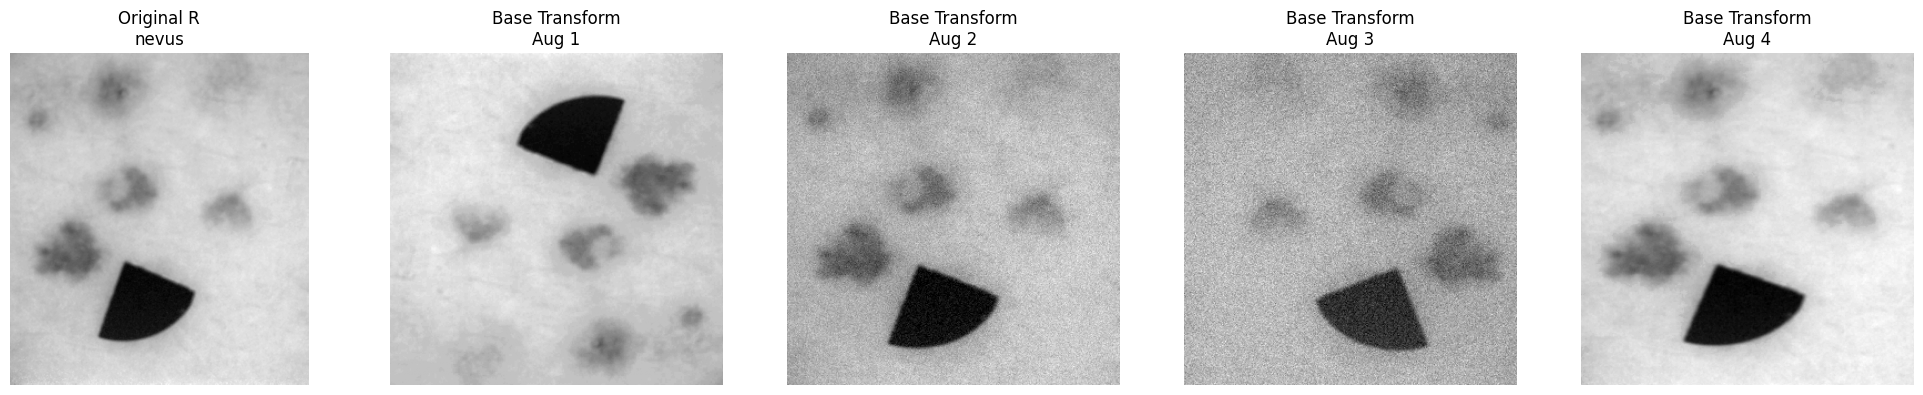

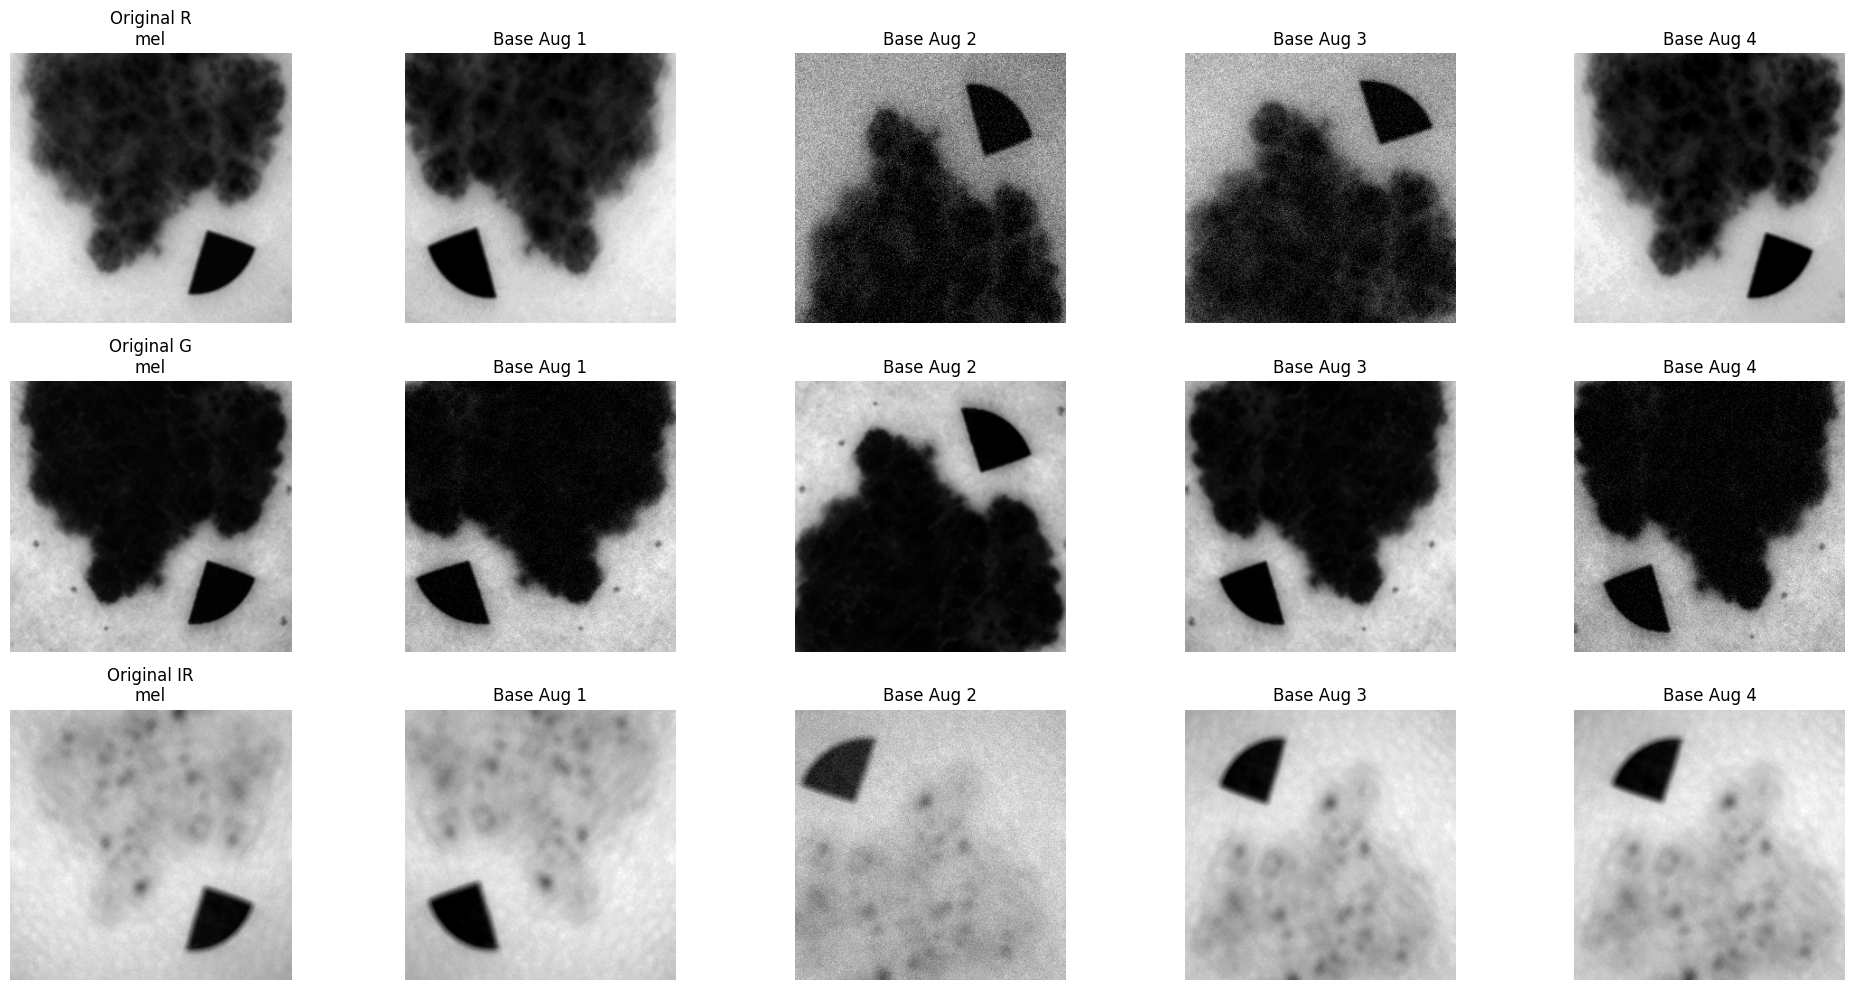

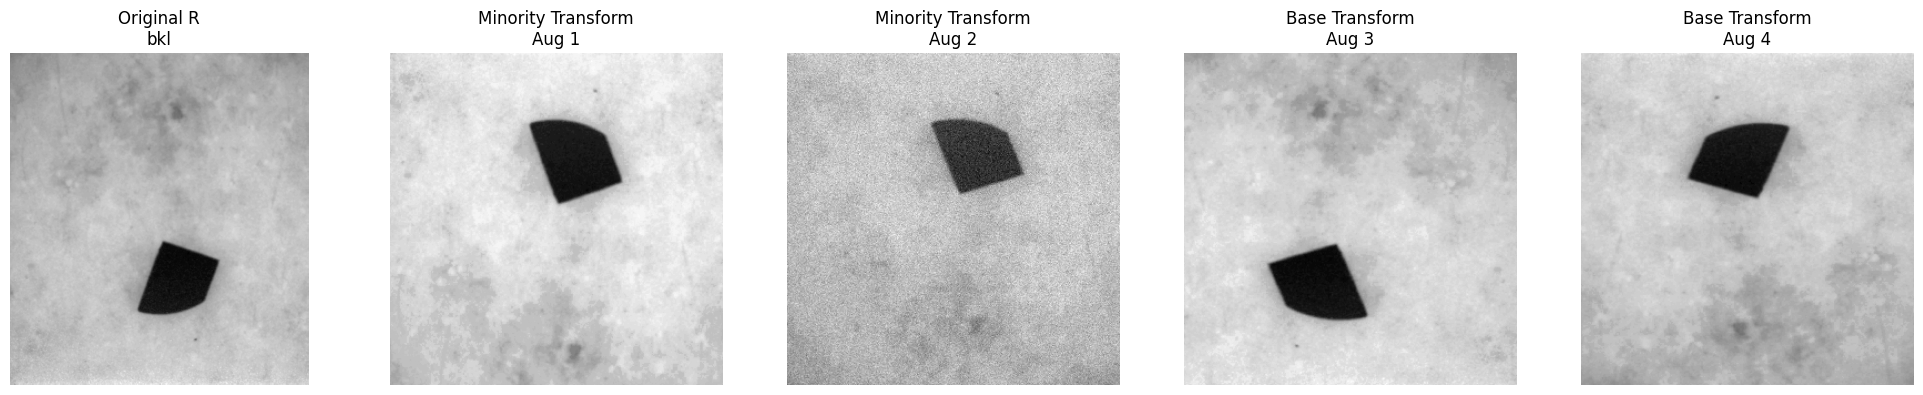

Loaded from Image_Preprocessing.ipynb


In [30]:
# Run Image_Preprocessing to load everything
%run "/home/i_am_helium/Code/Model Creation/Image Preprocessing.ipynb"

print("Loaded from Image_Preprocessing.ipynb")

### Clear GPU before loading

In [ ]:
import gc
import torch

print("Clearing GPU memory...")
torch.cuda.empty_cache()
gc.collect()

# Check memory
print(f"GPU memory allocated: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved(0)/1024**3:.2f} GB")

Clearing GPU memory...
GPU memory allocated: 0.02 GB
GPU memory reserved: 0.02 GB


### Progress

In [ ]:
import copy
import pickle
import gc

torch.cuda.empty_cache()
gc.collect()

num_classes = 4
fold_results = []

all_fold_train_losses = []
all_fold_val_losses = []
all_fold_train_accs = []
all_fold_val_accs = []
all_fold_train_bal_accs = []
all_fold_val_bal_accs = []
all_fold_train_f1s = []
all_fold_val_f1s = []


for fold_idx, train_fold_df, val_fold_df in folds:
    print(f"\n{'='*80}")
    print(f"FOLD {fold_idx+1}/{len(folds)}")
    print(f"{'='*80}")
    
    train_loader, val_loader = build_loaders_for_fold(
        train_fold_df, val_fold_df, batch_size=32
    )
    
    # Change to IMAGENET PRETRAINED
    print(f"\n{'='*60}")
    print(f"CREATING MODEL WITH IMAGENET PRETRAINED")
    print(f"{'='*60}")
    
    model = ImageOnlySkinNet(
        num_classes=num_classes,
        pretrained=True,  # ← Load ImageNet weights
        freeze_backbone=False,
        unfreeze_last_n_blocks=0
    ).to(device)
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"  Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
    print(f"✅ USING IMAGENET PRETRAINED WEIGHTS!\n")
    
    # Initialize tracking variables
    criterion = nn.CrossEntropyLoss()
    
    fold_train_losses = []
    fold_val_losses = []
    fold_train_accs = []
    fold_val_accs = []
    fold_train_bal_accs = []
    fold_val_bal_accs = []
    fold_train_f1s = []
    fold_val_f1s = []
    
    best_val_f1 = -float("inf")
    best_epoch = -1
    best_model_state = None
    
    # ===== PHASE 1: WARM-UP =====
    print(f"\n{'='*60}")
    print("--- Phase 1: Warm-up head only (5 epochs) ---")
    print(f"{'='*60}")
    
    for param in model.shared_backbone.parameters():
        param.requires_grad = False
    
    head_params = list(model.classifier.parameters())
    optimizer_p1 = optim.Adam(head_params, lr=1e-3)
    
    for epoch in range(5):
        train_loss, train_acc, train_bal_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer_p1, device
        )
        val_loss, val_acc, val_bal_acc, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )
        
        fold_train_losses.append(train_loss)
        fold_train_accs.append(train_acc)
        fold_train_bal_accs.append(train_bal_acc)
        fold_train_f1s.append(train_f1)
        fold_val_losses.append(val_loss)
        fold_val_accs.append(val_acc)
        fold_val_bal_accs.append(val_bal_acc)
        fold_val_f1s.append(val_f1)
        
        print(
            f"  [P1] Epoch {epoch+1}/5 | "
            f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}"
        )
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())
    
    # ===== PHASE 2: FINE-TUNE =====
    print(f"\n{'='*60}")
    print("--- Phase 2: Fine-tuning all layers (50 epochs) ---")
    print(f"{'='*60}")
    
    for param in model.shared_backbone.parameters():
        param.requires_grad = True
    
    backbone_params = list(model.shared_backbone.parameters())
    head_params = list(model.classifier.parameters())
    
    optimizer_p2 = optim.AdamW([
        {"params": backbone_params, "lr": 1e-4},
        {"params": head_params, "lr": 3e-4},
    ], weight_decay=1e-3, betas=(0.9, 0.999))
    
    scheduler = CosineAnnealingWarmRestarts(
        optimizer_p2, T_0=10, T_mult=2, eta_min=1e-6
    )
    
    patience = 12
    min_delta = 0.001
    epochs_without_improvement = 0
    
    for epoch in range(50):
        train_loss, train_acc, train_bal_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer_p2, device
        )
        val_loss, val_acc, val_bal_acc, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )
        
        scheduler.step()
        
        backbone_lr = optimizer_p2.param_groups[0]['lr']
        head_lr = optimizer_p2.param_groups[1]['lr']
        
        fold_train_losses.append(train_loss)
        fold_train_accs.append(train_acc)
        fold_train_bal_accs.append(train_bal_acc)
        fold_train_f1s.append(train_f1)
        fold_val_losses.append(val_loss)
        fold_val_accs.append(val_acc)
        fold_val_bal_accs.append(val_bal_acc)
        fold_val_f1s.append(val_f1)
        
        overall_epoch = 5 + epoch
        
        print(
            f"Epoch [{epoch+1}/50] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Train Bal Acc: {train_bal_acc:.4f} | Train Macro F1: {train_f1:.4f} || "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"Val Bal Acc: {val_bal_acc:.4f} | Val Macro F1: {val_f1:.4f} | "
            f"LR: backbone={backbone_lr:.2e}, head={head_lr:.2e}"
        )
        
        if val_f1 > best_val_f1 + min_delta:
            best_val_f1 = val_f1
            best_epoch = overall_epoch
            epochs_without_improvement = 0
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"  -> New best val_macro_f1: {best_val_f1:.4f}")
        else:
            epochs_without_improvement += 1
            print(f"  -> No improvement for {epochs_without_improvement}/{patience} epoch(s)")
        
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✓ Restored best model from epoch {best_epoch+1}")
    
    # Save checkpoint
    checkpoint = {
        'model_state_dict': best_model_state,
nỏ        'num_classes': num_classes,
        'best_epoch': best_epoch + 1,
        'best_val_f1': best_val_f1,
        'best_val_acc': fold_val_accs[best_epoch],
        'best_val_bal_acc': fold_val_bal_accs[best_epoch],
        'best_val_loss': fold_val_losses[best_epoch],
        'fold': fold_idx + 1,
        'architecture': 'efficientnet_b0',
        'pretrained': 'ImageNet',  # ← ĐỔI TÊN
        'training_mode': 'transfer_learning',
        'source': 'torchvision'
    }
    torch.save(checkpoint, f'imagenet_checkpoint_fold_{fold_idx+1}.pth')
    print(f"\n✓ Saved: imagenet_checkpoint_fold_{fold_idx+1}.pth")
    
    # Save results
    fold_results.append({
        "fold": fold_idx + 1,
        "train_losses": fold_train_losses,
        "val_losses": fold_val_losses,
        "train_accs": fold_train_accs,
        "val_accs": fold_val_accs,
        "train_bal_accs": fold_train_bal_accs,
        "val_bal_accs": fold_val_bal_accs,
        "train_f1s": fold_train_f1s,
        "val_f1s": fold_val_f1s,
        "stopped_epoch": len(fold_val_f1s),
        "best_epoch": best_epoch + 1,
        "final_val_loss": fold_val_losses[-1],
        "final_val_acc": fold_val_accs[-1],
        "final_val_bal_acc": fold_val_bal_accs[-1],
        "final_val_f1": fold_val_f1s[-1],
        "best_val_loss": fold_val_losses[best_epoch],
        "best_val_acc": fold_val_accs[best_epoch],
        "best_val_bal_acc": fold_val_bal_accs[best_epoch],
        "best_val_f1": best_val_f1,
        "best_model_state": copy.deepcopy(best_model_state)
    })
    
    all_fold_train_losses.append(fold_train_losses)
    all_fold_val_losses.append(fold_val_losses)
    all_fold_train_accs.append(fold_train_accs)
    all_fold_val_accs.append(fold_val_accs)
    all_fold_train_bal_accs.append(fold_train_bal_accs)
    all_fold_val_bal_accs.append(fold_val_bal_accs)
    all_fold_train_f1s.append(fold_train_f1s)
    all_fold_val_f1s.append(fold_val_f1s)
    
    del model
    torch.cuda.empty_cache()
    gc.collect()

# SUMMARY
print(f"\n{'='*80}")
print("ALL FOLDS COMPLETED!")
print(f"{'='*80}")

for fr in fold_results:
    print(f"Fold {fr['fold']}: val_f1={fr['best_val_f1']:.4f}, "
          f"val_acc={fr['best_val_acc']:.4f}, val_bal_acc={fr['best_val_bal_acc']:.4f}")

avg_f1 = sum(fr['best_val_f1'] for fr in fold_results) / len(fold_results)
avg_acc = sum(fr['best_val_acc'] for fr in fold_results) / len(fold_results)
avg_bal_acc = sum(fr['best_val_bal_acc'] for fr in fold_results) / len(fold_results)

print(f"\n{'='*80}")
print(f"AVERAGE ACROSS FOLDS:")
print(f"  F1: {avg_f1:.4f}")
print(f"  Acc: {avg_acc:.4f}")
print(f"  Bal Acc: {avg_bal_acc:.4f}")
print(f"{'='*80}")


FOLD 1/5

CREATING MODEL WITH IMAGENET PRETRAINED
  Trainable params: 4,499,136 / 4,499,136 (100.00%)
✅ USING IMAGENET PRETRAINED WEIGHTS!


--- Phase 1: Warm-up head only (5 epochs) ---
  [P1] Epoch 1/5 | Train F1: 0.5887 | Val F1: 0.6580
  [P1] Epoch 2/5 | Train F1: 0.6733 | Val F1: 0.5973
  [P1] Epoch 3/5 | Train F1: 0.7028 | Val F1: 0.6162
  [P1] Epoch 4/5 | Train F1: 0.7014 | Val F1: 0.6236
  [P1] Epoch 5/5 | Train F1: 0.7241 | Val F1: 0.6590

--- Phase 2: Fine-tuning all layers (50 epochs) ---
Epoch [1/50] | Train Loss: 0.6480 | Train Acc: 0.7482 | Train Bal Acc: 0.7474 | Train Macro F1: 0.7472 || Val Loss: 0.6884 | Val Acc: 0.7280 | Val Bal Acc: 0.6986 | Val Macro F1: 0.7016 | LR: backbone=9.76e-05, head=2.93e-04
  -> New best val_macro_f1: 0.7016
Epoch [2/50] | Train Loss: 0.5120 | Train Acc: 0.8050 | Train Bal Acc: 0.8051 | Train Macro F1: 0.8049 || Val Loss: 0.6699 | Val Acc: 0.7280 | Val Bal Acc: 0.7183 | Val Macro F1: 0.7079 | LR: backbone=9.05e-05, head=2.71e-04
  -> New 

### Evaluate

In [33]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for img_R, img_G, img_IR, labels in dataloader:
            img_R = img_R.to(device)
            img_G = img_G.to(device)
            img_IR = img_IR.to(device)
            labels = labels.to(device).long()

            outputs = model(img_R, img_G, img_IR)  # ✅ Truyền 3 tham số riêng
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return acc, bal_acc, precision, recall, f1, cm, all_labels, all_preds

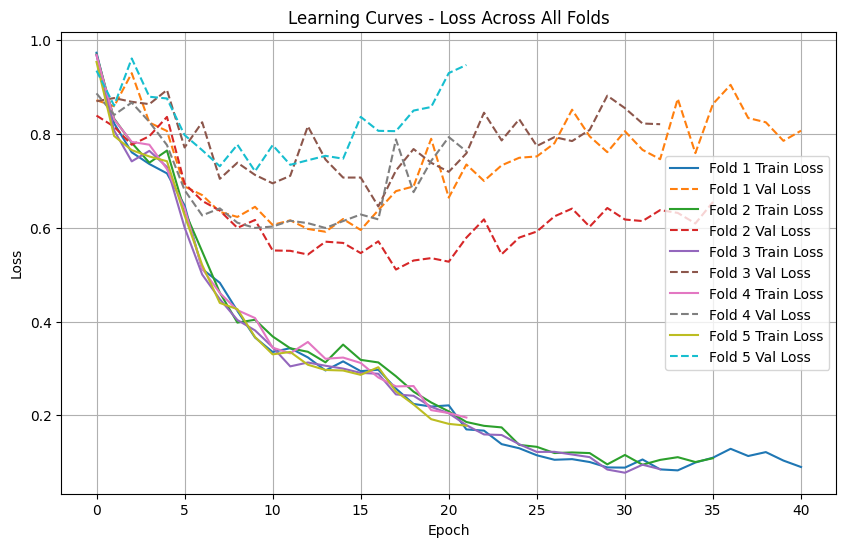

In [34]:
# ============================================================
# PLOT LEARNING CURVES - LOSS
# ============================================================

plt.figure(figsize=(10, 6))

for i in range(len(all_fold_train_losses)):
    plt.plot(all_fold_train_losses[i], label=f"Fold {i+1} Train Loss")
    plt.plot(all_fold_val_losses[i], linestyle='--', label=f"Fold {i+1} Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curves - Loss Across All Folds")
plt.legend()
plt.grid(True)
plt.show()

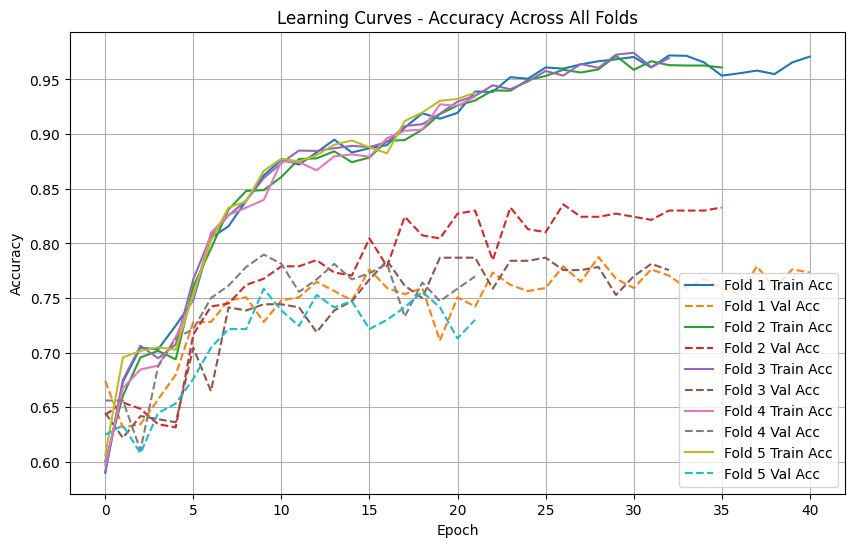

In [35]:
# ============================================================
# PLOT LEARNING CURVES - ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

for i in range(len(all_fold_train_accs)):
    plt.plot(all_fold_train_accs[i], label=f"Fold {i+1} Train Acc")
    plt.plot(all_fold_val_accs[i], linestyle='--', label=f"Fold {i+1} Val Acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curves - Accuracy Across All Folds")
plt.legend()
plt.grid(True)
plt.show()

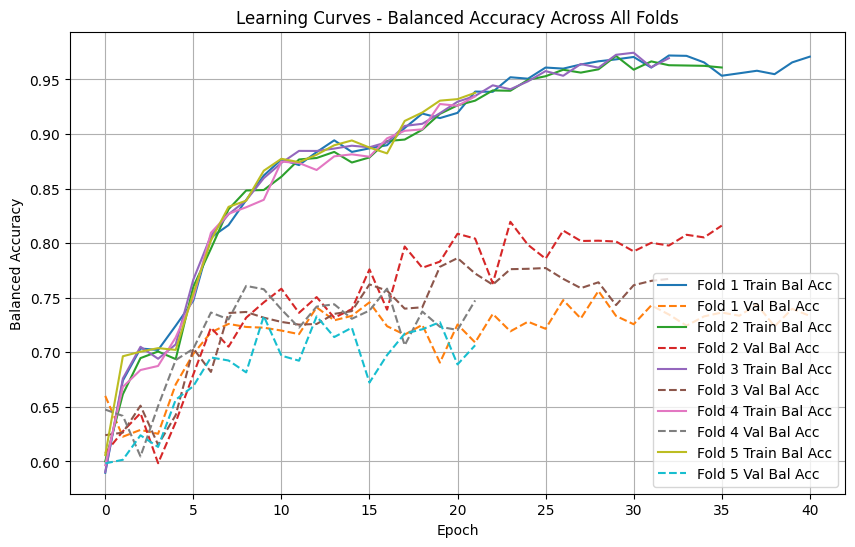

In [36]:
# ============================================================
# PLOT LEARNING CURVES - BALANCED ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

for i in range(len(all_fold_train_bal_accs)):
    plt.plot(all_fold_train_bal_accs[i], label=f"Fold {i+1} Train Bal Acc")
    plt.plot(all_fold_val_bal_accs[i], linestyle='--', label=f"Fold {i+1} Val Bal Acc")

plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.title("Learning Curves - Balanced Accuracy Across All Folds")
plt.legend()
plt.grid(True)
plt.show()

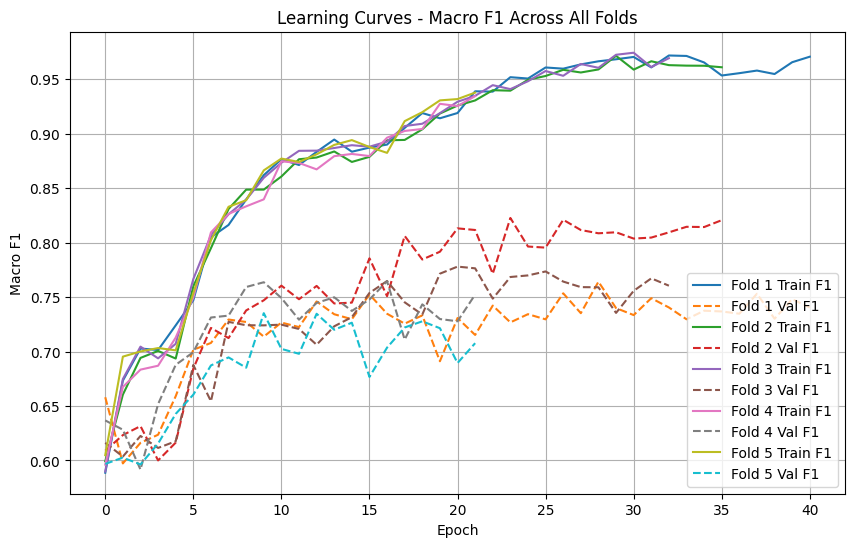

In [37]:
# ============================================================
# PLOT LEARNING CURVES - MACRO F1
# ============================================================

plt.figure(figsize=(10, 6))

for i in range(len(all_fold_train_f1s)):
    plt.plot(all_fold_train_f1s[i], label=f"Fold {i+1} Train F1")
    plt.plot(all_fold_val_f1s[i], linestyle='--', label=f"Fold {i+1} Val F1")

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Learning Curves - Macro F1 Across All Folds")
plt.legend()
plt.grid(True)
plt.show()

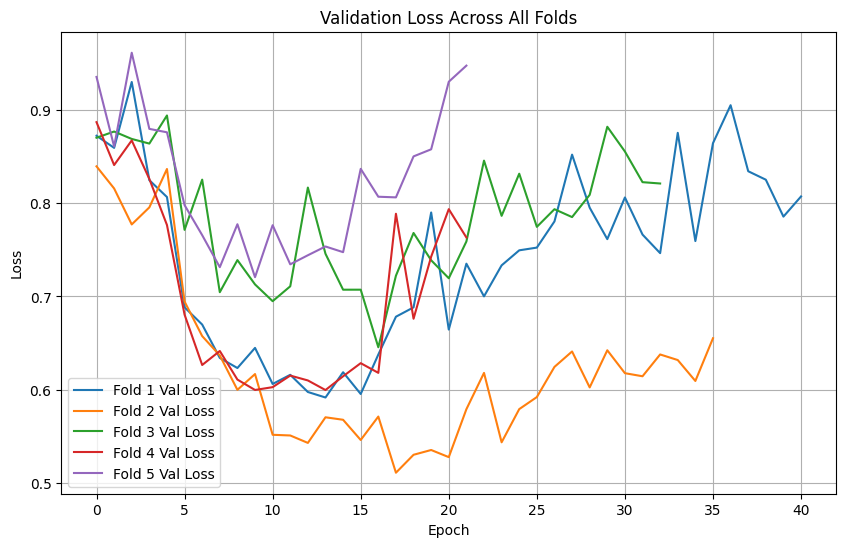

In [38]:
# ============================================================
# PLOT VALIDATION LOSS ONLY
# ============================================================

plt.figure(figsize=(10, 6))

for i in range(len(all_fold_val_losses)):
    plt.plot(all_fold_val_losses[i], label=f"Fold {i+1} Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Across All Folds")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# ROC CURVE & LOG LOSS FUNCTIONS
# ============================================================

from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

def plot_roc_curve(model, loader, device, label_names):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for img_R, img_G, img_IR, labels in loader:
            img_R = img_R.to(device)
            img_G = img_G.to(device)
            img_IR = img_IR.to(device)
            
            outputs = model(img_R, img_G, img_IR)  # ✅
            probs = F.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    n_classes = len(label_names)
    plt.figure(figsize=(8, 6))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label_names[i]} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (One-vs-Rest)')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


def compute_log_loss(model, loader, device):
    from sklearn.metrics import log_loss

    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for img_R, img_G, img_IR, labels in loader:
            img_R = img_R.to(device)
            img_G = img_G.to(device)
            img_IR = img_IR.to(device)
            
            outputs = model(img_R, img_G, img_IR)  
            probs = F.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    loss = log_loss(all_labels, all_probs)
    print(f"Log Loss: {loss:.4f}")
    return loss

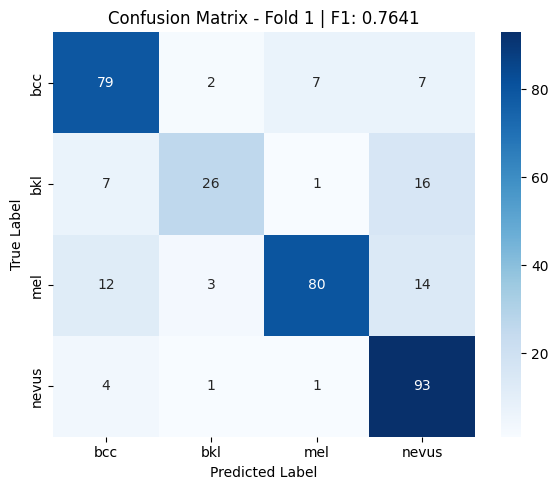


Fold 1 — Per-class metrics:
              precision    recall  f1-score   support

         bcc     0.7745    0.8316    0.8020        95
         bkl     0.8125    0.5200    0.6341        50
         mel     0.8989    0.7339    0.8081       109
       nevus     0.7154    0.9394    0.8122        99

    accuracy                         0.7875       353
   macro avg     0.8003    0.7562    0.7641       353
weighted avg     0.8017    0.7875    0.7830       353

Cohen's Kappa: 0.7083
MCC:           0.7152


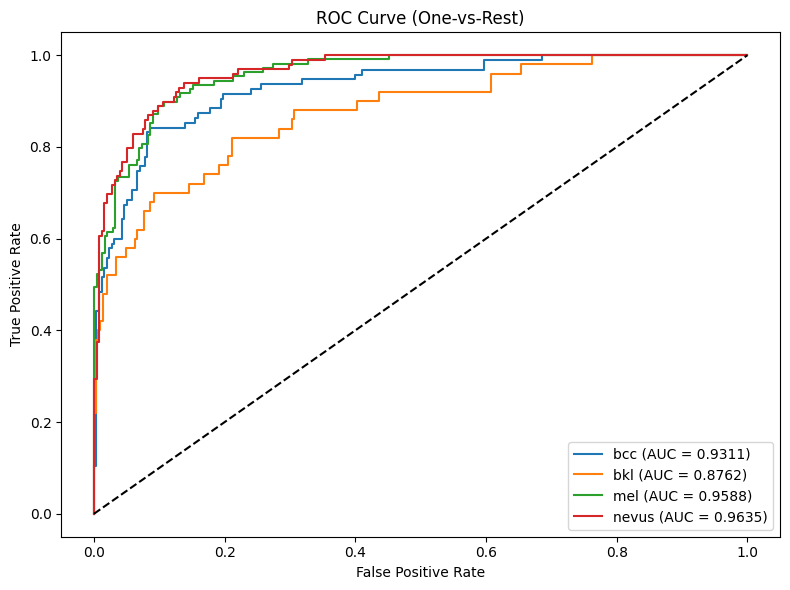

Log Loss: 0.8627


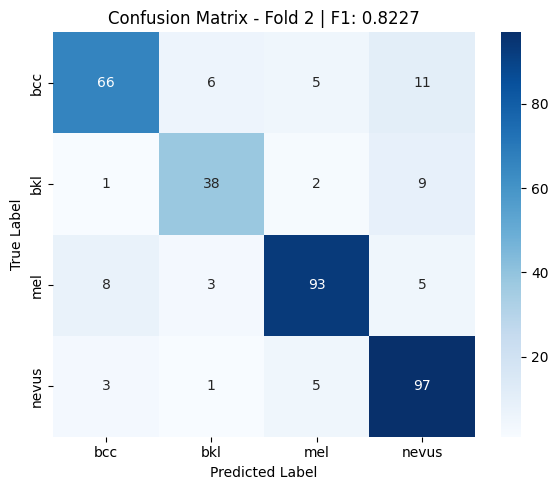


Fold 2 — Per-class metrics:
              precision    recall  f1-score   support

         bcc     0.8462    0.7500    0.7952        88
         bkl     0.7917    0.7600    0.7755        50
         mel     0.8857    0.8532    0.8692       109
       nevus     0.7951    0.9151    0.8509       106

    accuracy                         0.8329       353
   macro avg     0.8297    0.8196    0.8227       353
weighted avg     0.8353    0.8329    0.8320       353

Cohen's Kappa: 0.7711
MCC:           0.7727


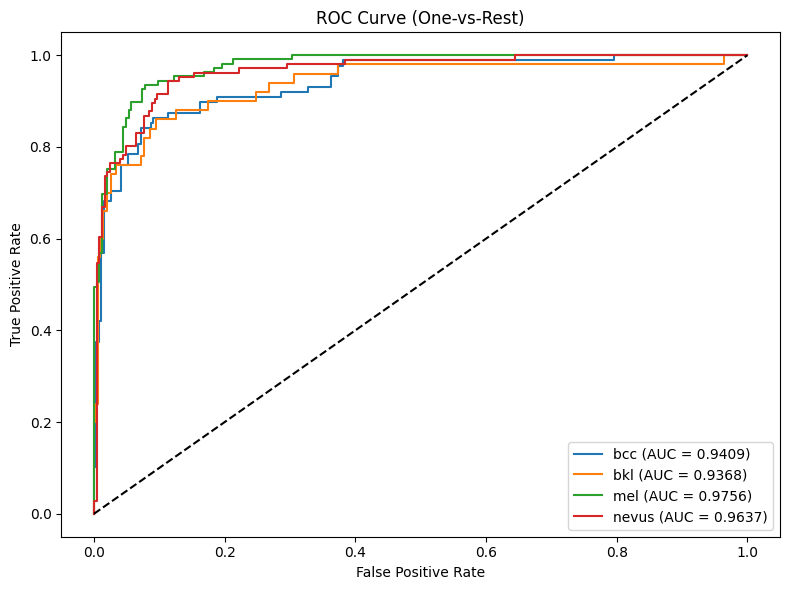

Log Loss: 0.5912


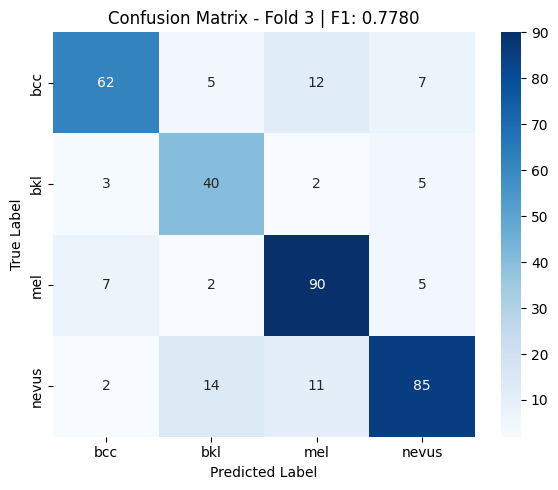


Fold 3 — Per-class metrics:
              precision    recall  f1-score   support

         bcc     0.8378    0.7209    0.7750        86
         bkl     0.6557    0.8000    0.7207        50
         mel     0.7826    0.8654    0.8219       104
       nevus     0.8333    0.7589    0.7944       112

    accuracy                         0.7869       352
   macro avg     0.7774    0.7863    0.7780       352
weighted avg     0.7942    0.7869    0.7873       352

Cohen's Kappa: 0.7102
MCC:           0.7121


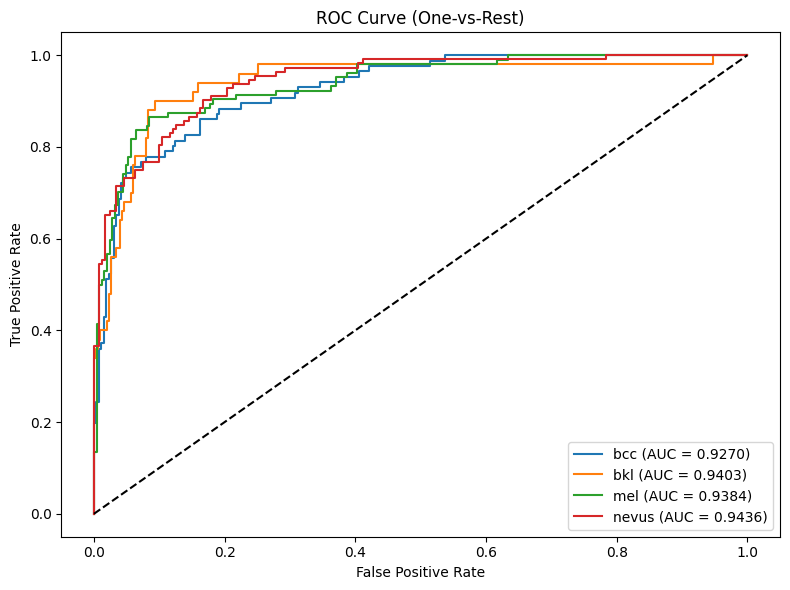

Log Loss: 0.7196


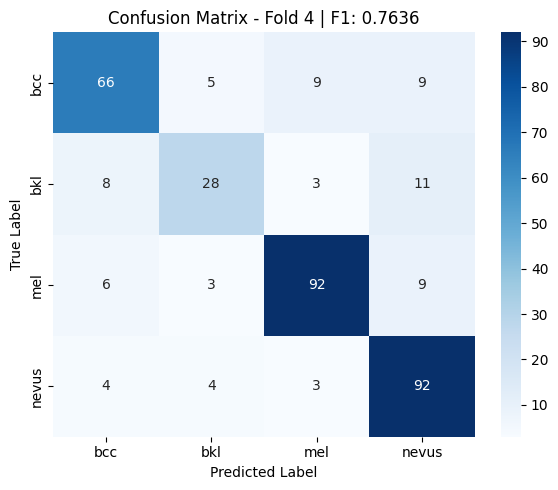


Fold 4 — Per-class metrics:
              precision    recall  f1-score   support

         bcc     0.7857    0.7416    0.7630        89
         bkl     0.7000    0.5600    0.6222        50
         mel     0.8598    0.8364    0.8479       110
       nevus     0.7603    0.8932    0.8214       103

    accuracy                         0.7898       352
   macro avg     0.7765    0.7578    0.7636       352
weighted avg     0.7893    0.7898    0.7866       352

Cohen's Kappa: 0.7112
MCC:           0.7130


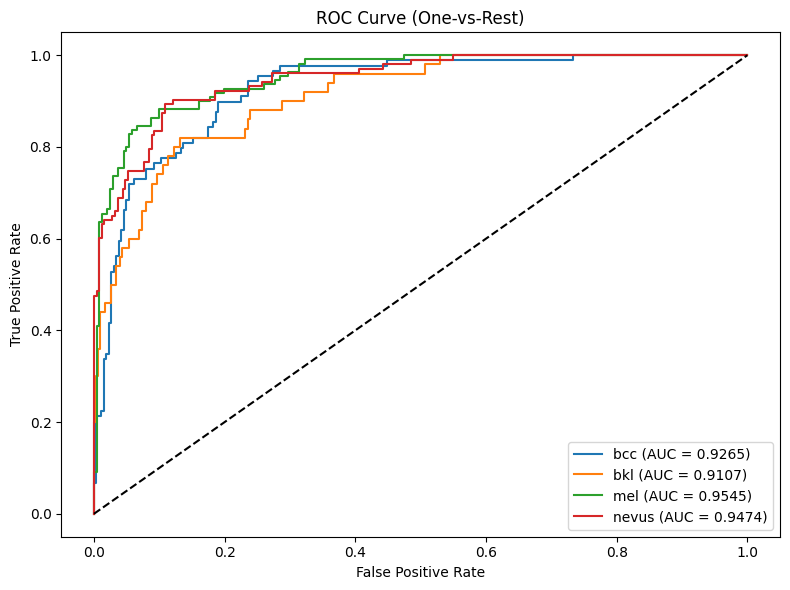

Log Loss: 0.5998


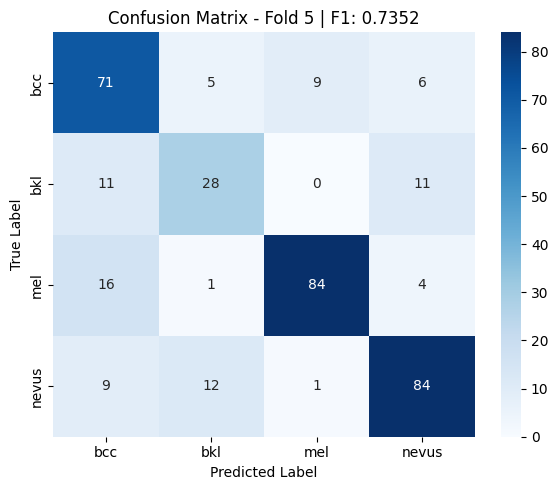


Fold 5 — Per-class metrics:
              precision    recall  f1-score   support

         bcc     0.6636    0.7802    0.7172        91
         bkl     0.6087    0.5600    0.5833        50
         mel     0.8936    0.8000    0.8442       105
       nevus     0.8000    0.7925    0.7962       106

    accuracy                         0.7585       352
   macro avg     0.7415    0.7332    0.7352       352
weighted avg     0.7655    0.7585    0.7599       352

Cohen's Kappa: 0.6707
MCC:           0.6722


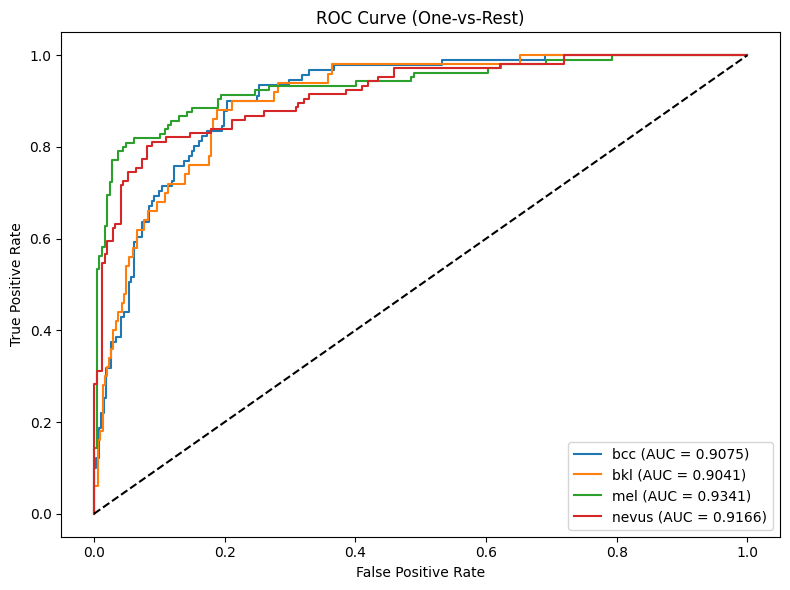

Log Loss: 0.7207


In [ ]:
# ============================================================
# DETAILED METRICS PER FOLD
# ============================================================
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, classification_report
import seaborn as sns

label_names = ['bcc', 'bkl', 'mel', 'nevus']  # ← 4 classes from skin dataset
    
for fr in fold_results:
    fold_idx = fr['fold'] - 1
    _, train_fold_df, val_fold_df = folds[fold_idx]
    _, val_loader = build_loaders_for_fold(train_fold_df, val_fold_df)
    
    # LOAD MODEL với đúng class name và num_classes
    model_eval = ImageOnlySkinNet(num_classes=4).to(device)  # ← 4 classes
    model_eval.load_state_dict(fr['best_model_state'])
    model_eval.eval()
    
    # Evaluate
    acc, bal_acc, precision, recall, f1, cm, all_labels, all_preds = evaluate_model(
        model_eval, val_loader, device
    )
    
    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=label_names, yticklabels=label_names, cmap='Blues')
    plt.title(f"Confusion Matrix - Fold {fr['fold']} | F1: {f1:.4f}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # Per-class metrics
    print(f"\nFold {fr['fold']} — Per-class metrics:")
    print(classification_report(all_labels, all_preds, target_names=label_names, digits=4))
    
    # Extra metrics
    kappa = cohen_kappa_score(all_labels, all_preds)
    mcc = matthews_corrcoef(all_labels, all_preds)
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"MCC:           {mcc:.4f}")
    
    # ROC curve
    plot_roc_curve(model_eval, val_loader, device, label_names)
    
    # Log loss
    compute_log_loss(model_eval, val_loader, device)

In [41]:
# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

print(f"\n{'='*60}")
print("FINAL RESULTS ACROSS ALL FOLDS")
print(f"{'='*60}")
print(f"{'Fold':<8} {'Best Epoch':<12} {'Val Acc':<10} {'Val Bal Acc':<14} {'Val F1'}")
print(f"{'='*60}")
for fr in fold_results:
    print(f"{fr['fold']:<8} {fr['best_epoch']:<12} {fr['best_val_acc']:.4f}     {fr['best_val_bal_acc']:.4f}         {fr['best_val_f1']:.4f}")
print(f"{'='*60}")
best_f1s = [fr['best_val_f1'] for fr in fold_results]
best_accs = [fr['best_val_acc'] for fr in fold_results]
print(f"Mean F1:  {np.mean(best_f1s):.4f} ± {np.std(best_f1s):.4f}")
print(f"Mean Acc: {np.mean(best_accs):.4f} ± {np.std(best_accs):.4f}")


FINAL RESULTS ACROSS ALL FOLDS
Fold     Best Epoch   Val Acc    Val Bal Acc    Val F1
1        29           0.7875     0.7562         0.7641
2        24           0.8329     0.8196         0.8227
3        21           0.7869     0.7863         0.7780
4        10           0.7898     0.7578         0.7636
5        10           0.7585     0.7332         0.7352
Mean F1:  0.7727 ± 0.0286
Mean Acc: 0.7911 ± 0.0238
